In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ta

In [2]:
df = pd.read_csv("../data/processed/HDFCBANK_cleaned.csv")

In [4]:
df["SMA_20"] = df["Close"].rolling(window=20).mean()

In [5]:
df["SMA_50"] = df["Close"].rolling(window=50).mean()

In [6]:
df[["Close", "SMA_20", "SMA_50"]].tail()

,Close,SMA_20,SMA_50
1607,796.299988,756.242462,760.845159
1608,796.299988,759.435666,761.033451
1609,798.900024,762.849866,761.361296
1610,797.950012,765.943579,761.349446
1611,796.150024,768.681686,761.534739


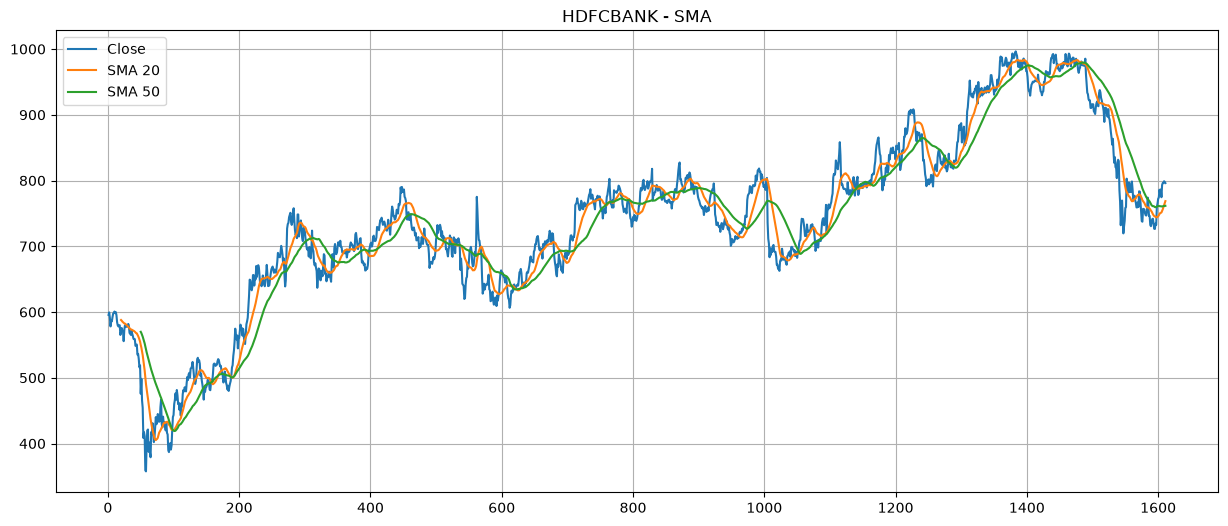

In [7]:
plt.figure(figsize=(15,6))

plt.plot(df["Close"], label="Close")
plt.plot(df["SMA_20"], label="SMA 20")
plt.plot(df["SMA_50"], label="SMA 50")

plt.title("HDFCBANK - SMA")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()

In [9]:
df["RSI"] = ta.momentum.RSIIndicator(df["Close"], window=14).rsi()

In [10]:
df[["Close", "RSI"]].tail()

,Close,RSI
1607,796.299988,64.372441
1608,796.299988,64.372441
1609,798.900024,65.260732
1610,797.950012,64.626694
1611,796.150024,63.370446


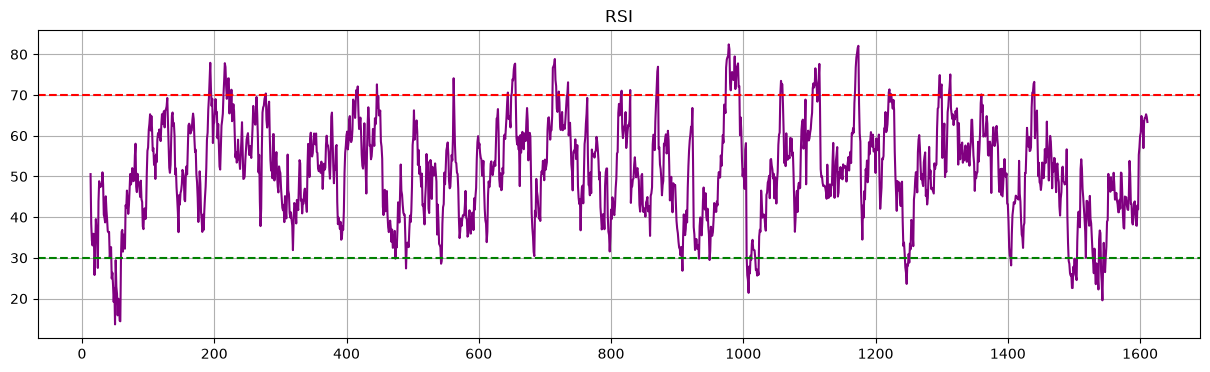

In [11]:
plt.figure(figsize=(15,4))

plt.plot(df["RSI"], color="purple")

plt.axhline(70, color="red", linestyle="--")
plt.axhline(30, color="green", linestyle="--")

plt.title("RSI")
plt.grid(True)

plt.show()

In [12]:
macd = ta.trend.MACD(df["Close"])

df["MACD"] = macd.macd()
df["MACD_Signal"] = macd.macd_signal()

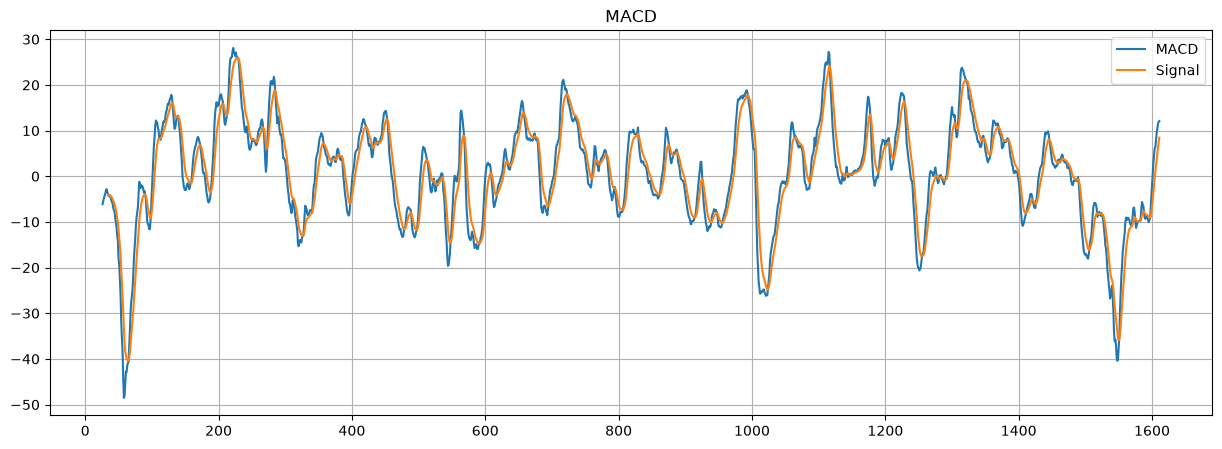

In [13]:
plt.figure(figsize=(15,5))

plt.plot(df["MACD"], label="MACD")
plt.plot(df["MACD_Signal"], label="Signal")

plt.legend()
plt.title("MACD")
plt.grid(True)

plt.show()

In [15]:
bb = ta.volatility.BollingerBands(df["Close"], window=20)

df["BB_High"] = bb.bollinger_hband()
df["BB_Low"] = bb.bollinger_lband()

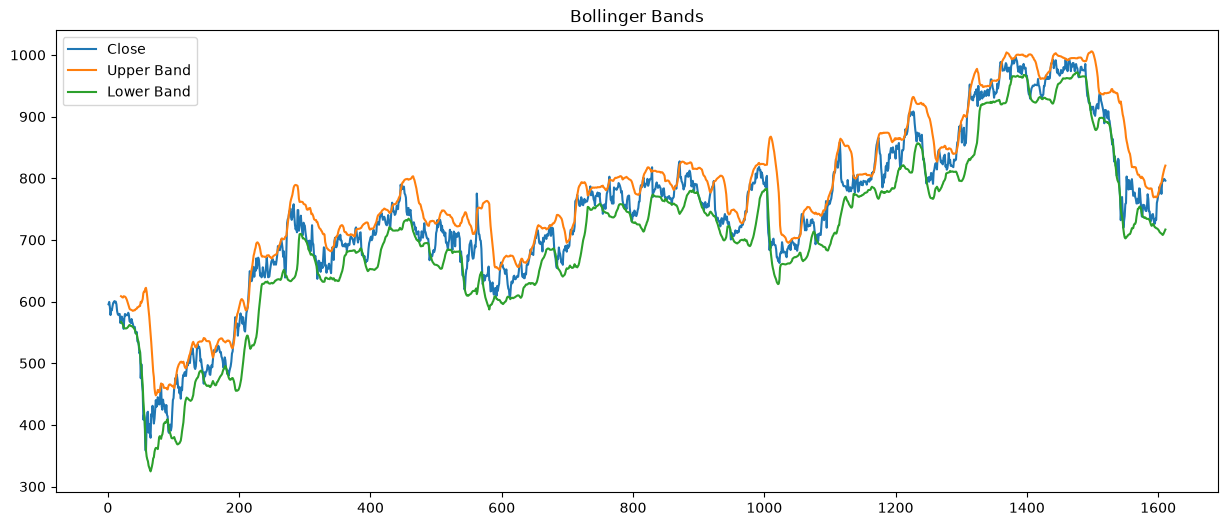

In [16]:
plt.figure(figsize=(15,6))

plt.plot(df["Close"], label="Close")
plt.plot(df["BB_High"], label="Upper Band")
plt.plot(df["BB_Low"], label="Lower Band")

plt.legend()
plt.title("Bollinger Bands")

plt.show()

In [17]:
atr = ta.volatility.AverageTrueRange(
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    window=14
)

df["ATR"] = atr.average_true_range()

In [18]:
df[["Close", "ATR"]].tail()

,Close,ATR
1607,796.299988,15.725959
1608,796.299988,14.602676
1609,798.900024,14.459630
1610,797.950012,14.380369
1611,796.150024,13.978200


In [19]:
    df.dropna(inplace=True)

In [20]:
df.isnull().sum()

Unnamed: 0      0
Price           0
Close           0
High            0
Low             0
Open            0
Volume          0
Daily_Return    0
SMA_20          0
SMA_50          0
EMA_20          0
RSI             0
MACD            0
MACD_Signal     0
BB_High         0
BB_Low          0
ATR             0
dtype: int64

In [21]:
df.to_csv("../data/processed/HDFCBANK_features.csv")